<a href="https://colab.research.google.com/github/Rahuldeb55/Machine-learning-laboratory/blob/main/lab_03/Linear_reg_(grad_desc)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

X_b = np.c_[np.ones((100, 1)), X]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Shape of X_b (with bias): {X_b.shape}")

Shape of X: (100, 1)
Shape of y: (100, 1)
Shape of X_b (with bias): (100, 2)


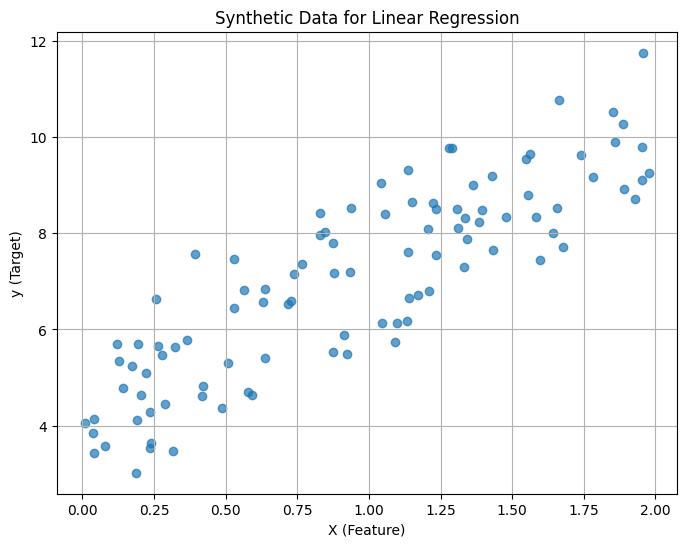

In [2]:
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.7)
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Synthetic Data for Linear Regression')
plt.grid(True)
plt.show()

In [3]:
def hypothesis(X, theta):
    return X @ theta

def compute_cost(X, y, theta):
    m = len(y)
    predictions = hypothesis(X, theta)
    sq_error = (predictions - y)**2
    return (1/(2*m)) * np.sum(sq_error)

theta = np.random.randn(2, 1)

print(f"Initial Theta: \n{theta}")
print(f"Initial Cost: {compute_cost(X_b, y, theta):.4f}")

Initial Theta: 
[[-0.35399391]
 [-1.37495129]]
Initial Cost: 41.3315


In [4]:
def gradient_descent(X, y, theta, learning_rate, n_iterations):
    m = len(y)
    cost_history = []

    for iteration in range(n_iterations):
        predictions = hypothesis(X, theta)
        errors = predictions - y
        gradients = (1/m) * X.T @ errors
        theta = theta - learning_rate * gradients

        cost = compute_cost(X, y, theta)
        cost_history.append(cost)

    return theta, cost_history

In [5]:
learning_rate = 0.01
n_iterations = 1000

theta = np.random.randn(2, 1)

final_theta, cost_history = gradient_descent(X_b, y, theta, learning_rate, n_iterations)

print(f"Optimized Theta (Intercept, Slope): \n{final_theta}")
print(f"Final Cost: {cost_history[-1]:.4f}")

Optimized Theta (Intercept, Slope): 
[[4.19322431]
 [2.99413508]]
Final Cost: 0.4963


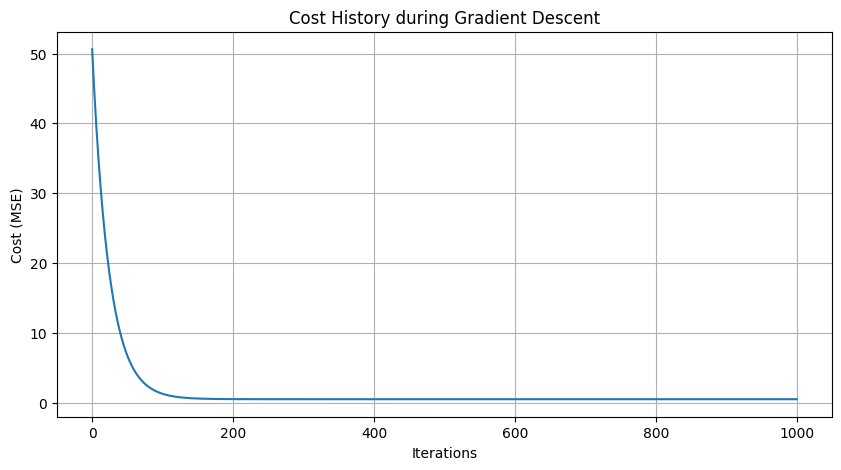

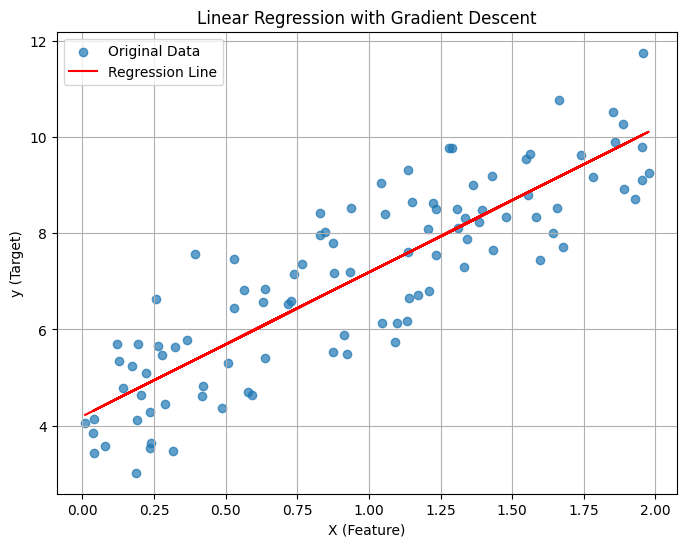

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(range(n_iterations), cost_history)
plt.xlabel('Iterations')
plt.ylabel('Cost (MSE)')
plt.title('Cost History during Gradient Descent')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.7, label='Original Data')
plt.plot(X, hypothesis(X_b, final_theta), color='red', label='Regression Line')
plt.xlabel('X (Feature)')
plt.ylabel('y (Target)')
plt.title('Linear Regression with Gradient Descent')
plt.legend()
plt.grid(True)
plt.show()